# Class 비율

2시리즈_액티브_투어러_F45_2019_2021 64
K5_3세대_하이브리드_2020_2022 57
뉴_QM6_2021_2023 59
디_올_뉴_스포티지_2022_2024 60
마칸_2022_2024 65
스타리아_2022_2025 66
트레일블레이저_2023 65
티볼리_에어_2021_2022 66


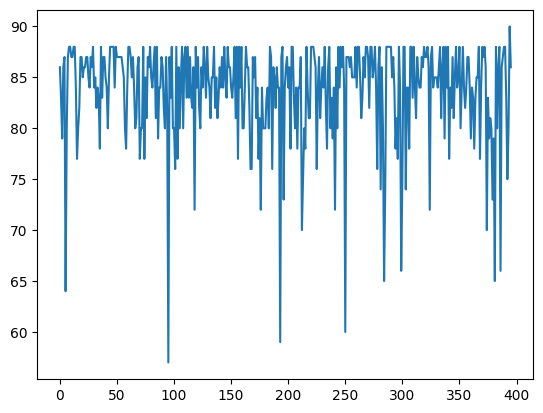

In [1]:
import os
import matplotlib.pyplot as plt
data = []
path = './train'
for filename in sorted(os.listdir("./train")):
    data.append(len(os.listdir(os.path.join(path, filename))))
    if data[-1] < 70:
        print(filename, data[-1])

plt.plot(data)

# 이미지 해상도

In [2]:
import cv2, glob, tqdm
import numpy as np
# datas = []
filenames = []
res = []
for filename in tqdm.tqdm(glob.glob("./train/*/*.jpg")):
    filename = filename.replace("\\", "/")
    image_array = np.fromfile(filename, np.uint8)
    image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    # datas.append(image)
    res.append(image.shape)
    filenames.append(filename)
res = np.array(res, dtype=np.float32)
ratio = res[:, 0] / res[:, 1]

100%|██████████| 33137/33137 [00:47<00:00, 691.05it/s]


In [3]:
res

array([[428., 822.,   3.],
       [433., 553.,   3.],
       [361., 784.,   3.],
       ...,
       [423., 769.,   3.],
       [434., 725.,   3.],
       [417., 516.,   3.]], dtype=float32)

In [4]:
ratio

array([0.52068126, 0.7830018 , 0.46045917, ..., 0.55006504, 0.5986207 ,
       0.80813956], dtype=float32)

In [22]:
import shutil, os
shutil.rmtree("./selected")
os.makedirs("./selected")

for i, r in enumerate(ratio):
    basename = filenames[i].split("/")[-1]
    if r <0.3: 
        print(filenames[i])

        shutil.copy(filenames[i], os.path.join("./selected", f"{r}_{basename}"))


./test/TEST_00425.jpg
./test/TEST_00530.jpg
./test/TEST_00751.jpg
./test/TEST_00780.jpg
./test/TEST_00992.jpg
./test/TEST_01063.jpg
./test/TEST_01140.jpg
./test/TEST_01255.jpg
./test/TEST_01505.jpg
./test/TEST_01782.jpg
./test/TEST_01817.jpg
./test/TEST_01942.jpg
./test/TEST_02003.jpg
./test/TEST_02049.jpg
./test/TEST_02578.jpg
./test/TEST_02653.jpg
./test/TEST_03003.jpg
./test/TEST_03104.jpg
./test/TEST_03453.jpg
./test/TEST_03960.jpg
./test/TEST_04005.jpg
./test/TEST_04340.jpg
./test/TEST_04419.jpg
./test/TEST_04467.jpg
./test/TEST_04718.jpg
./test/TEST_04785.jpg
./test/TEST_04819.jpg
./test/TEST_04827.jpg
./test/TEST_04910.jpg
./test/TEST_05738.jpg
./test/TEST_05754.jpg
./test/TEST_05945.jpg
./test/TEST_06117.jpg
./test/TEST_06157.jpg
./test/TEST_06186.jpg
./test/TEST_06229.jpg
./test/TEST_06240.jpg
./test/TEST_06317.jpg
./test/TEST_06487.jpg
./test/TEST_06512.jpg
./test/TEST_06544.jpg
./test/TEST_06921.jpg
./test/TEST_06996.jpg
./test/TEST_07125.jpg
./test/TEST_07254.jpg
./test/TES

In [20]:
import cv2, glob, tqdm
import numpy as np
# datas = []
filenames = []
res = []
for filename in tqdm.tqdm(glob.glob("./test/*.jpg")):
    filename = filename.replace("\\", "/")
    image_array = np.fromfile(filename, np.uint8)
    image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    # datas.append(image)
    res.append(image.shape)
    filenames.append(filename)
res = np.array(res, dtype=np.float32)
ratio = res[:, 0] / res[:, 1]

100%|██████████| 8258/8258 [00:52<00:00, 156.23it/s]


# K-Fold index 설정

In [1]:
import os, tqdm
import numpy as np
root_dir='./dataset/data/train'

samples = []

classes = sorted(os.listdir(root_dir))
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

data = [[] for _ in range(len(classes))]

for cls_idx, cls_name in enumerate(tqdm.tqdm(classes, desc='Processing')):
    cls_folder = os.path.join(root_dir, cls_name)
    for fname in sorted(os.listdir(cls_folder)):
        if fname.lower().endswith(('.jpg')):
            image_path = os.path.join(cls_folder, fname)
            target = cls_idx
            data[cls_idx].append([image_path, target])

Processing:   0%|          | 0/396 [00:00<?, ?it/s]

Processing: 100%|██████████| 396/396 [00:00<00:00, 3461.80it/s]


In [2]:
def split_list(lst, n):
    k, m = divmod(len(lst), n)
    return [lst[i*k + min(i, m):(i+1)*k + min(i+1, m)] for i in range(n)]

rng = np.random.RandomState(42)
folded = [split_list(rng.permutation(range(len(data[i]))).tolist(), n=5) for i in range(len(data))] # 각 파트는 Validation index들을 의미함
folded

[[[75, 0, 70, 22, 12, 56, 10, 18, 4, 67, 61, 64, 53, 73, 62, 66, 33, 78],
  [54, 72, 11, 30, 40, 28, 9, 65, 5, 39, 31, 35, 45, 44, 16, 42, 34],
  [7, 49, 82, 19, 83, 25, 47, 13, 24, 3, 17, 38, 8, 68, 6, 55, 36],
  [77, 85, 43, 50, 46, 84, 15, 69, 27, 41, 58, 26, 48, 76, 57, 32, 81],
  [59, 63, 79, 37, 29, 1, 52, 21, 2, 23, 80, 74, 20, 60, 71, 14, 51]],
 [[80, 42, 61, 60, 49, 20, 41, 15, 17, 77, 5, 82, 78, 38, 31, 9, 1],
  [56, 24, 37, 71, 45, 58, 29, 55, 65, 3, 19, 16, 63, 30, 18, 12, 50],
  [35, 79, 72, 48, 51, 25, 66, 46, 2, 13, 53, 57, 74, 52, 26, 21, 39],
  [43, 68, 36, 23, 22, 54, 47, 67, 33, 11, 76, 75, 6, 27, 81, 4],
  [32, 69, 34, 73, 10, 62, 7, 0, 8, 70, 64, 44, 14, 28, 40, 59]],
 [[66, 45, 9, 73, 47, 14, 20, 17, 13, 12, 29, 33, 7, 68, 46, 41],
  [6, 30, 35, 55, 24, 28, 72, 42, 39, 15, 34, 21, 37, 40, 19, 4],
  [67, 59, 10, 3, 60, 5, 44, 25, 75, 18, 0, 32, 65, 53, 22, 27],
  [49, 56, 52, 16, 54, 70, 62, 77, 1, 38, 11, 64, 57, 63, 74, 48],
  [51, 31, 58, 23, 43, 50, 36, 78, 8, 